<a href="https://colab.research.google.com/github/Chandhana-sanoj/ICT_DSA_2026/blob/main/data_preprocessing_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dataset Overview


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#used for scaling and  Encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [35]:
house_df = pd.read_csv("House_Pricing.csv")

In [36]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [37]:
house_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [38]:
house_df.head(2)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639


#Duplicate Removal

In [39]:
duplicate_rows = house_df.duplicated().sum()  # Check duplicate rows

In [40]:
print( duplicate_rows)

0


In [41]:
duplicate_cols = house_df.T.duplicated().sum()  # Check duplicate columns

In [42]:
print(duplicate_cols)

0


In [43]:
#Checked for duplicate rows and columns in the dataset. No duplicates were found, so no removal was required.

#Handling Missing Values

In [44]:
house_df.isna()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [45]:
house_df.isnull()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21609,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21610,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
21611,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [46]:
house_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [47]:
missing_percent = house_df.isna().sum() / len(house_df) * 100
missing_percent = missing_percent[missing_percent > 0]
missing_percent.sort_values(ascending=False)

,0
No of Times Visited,90.172581
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
Sale Price,0.018507
No of Bathrooms,0.018507
Area of the House from Basement (in Sqft),0.013881
Zipcode,0.004627
Latitude,0.004627
Longitude,0.004627
Living Area after Renovation (in Sqft),0.004627


In [48]:
num_cols = house_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = house_df.select_dtypes(include=['object']).columns

In [49]:
num_cols

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [50]:
cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

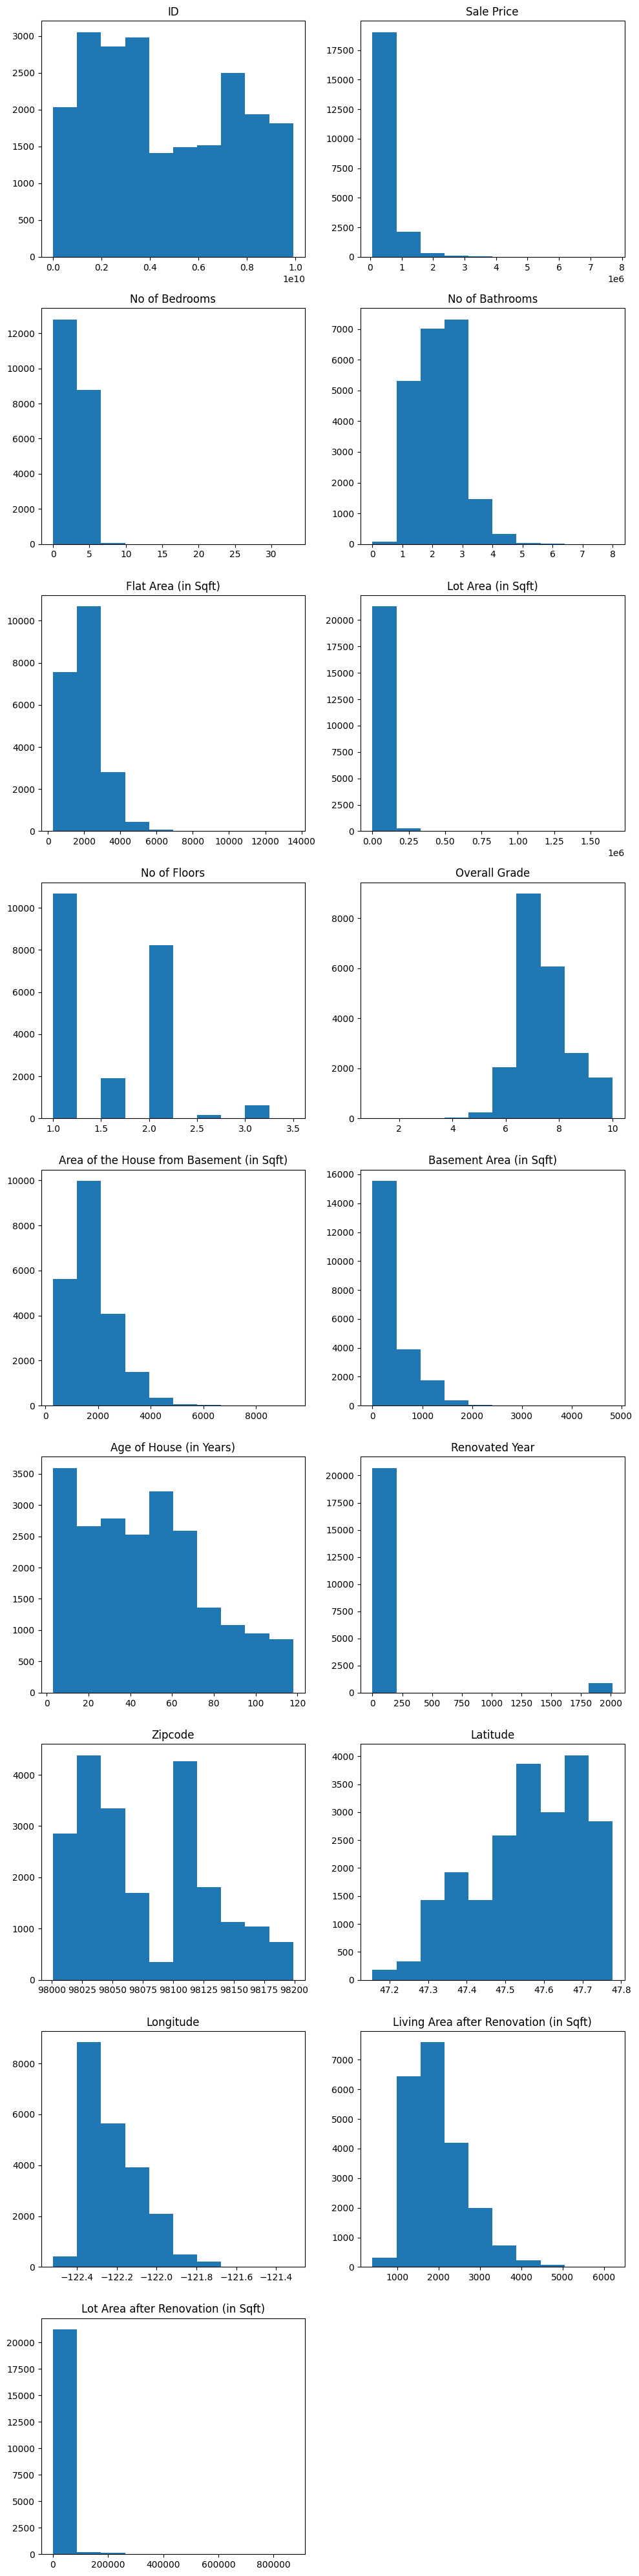

In [51]:
plt.figure(figsize=(10,40))
for i, col in enumerate(num_cols, 1):
    plt.subplot(9,2, i)
    plt.hist(house_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [52]:
#from the chart,we sww that al,colums are skewed in natrue.
#we can use median to replace every column

house_df['No of Bedrooms'].fillna(house_df['No of Bedrooms'].median(), inplace=True)
house_df['No of Bathrooms'].fillna(house_df['No of Bathrooms'].median(), inplace=True)
house_df['Flat Area (in Sqft)'].fillna(house_df['Flat Area (in Sqft)'].median(), inplace=True)
house_df['Lot Area (in Sqft)'].fillna(house_df['Lot Area (in Sqft)'].median(), inplace=True)
house_df['No of Floors'].fillna(house_df['No of Floors'].median(), inplace=True)
house_df['Overall Grade'].fillna(house_df['Overall Grade'].median(), inplace=True)
house_df['Basement Area (in Sqft)'].fillna(house_df['Basement Area (in Sqft)'].median(), inplace=True)
house_df['Age of House (in Years)'].fillna(house_df['Age of House (in Years)'].median(), inplace=True)
house_df['Renovated Year'].fillna(house_df['Renovated Year'].median(), inplace=True)

house_df.isna().sum()

/tmp/ipykernel_1250/2095754791.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house_df['No of Bedrooms'].fillna(house_df['No of Bedrooms'].median(), inplace=True)
/tmp/ipykernel_1250/2095754791.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,19489


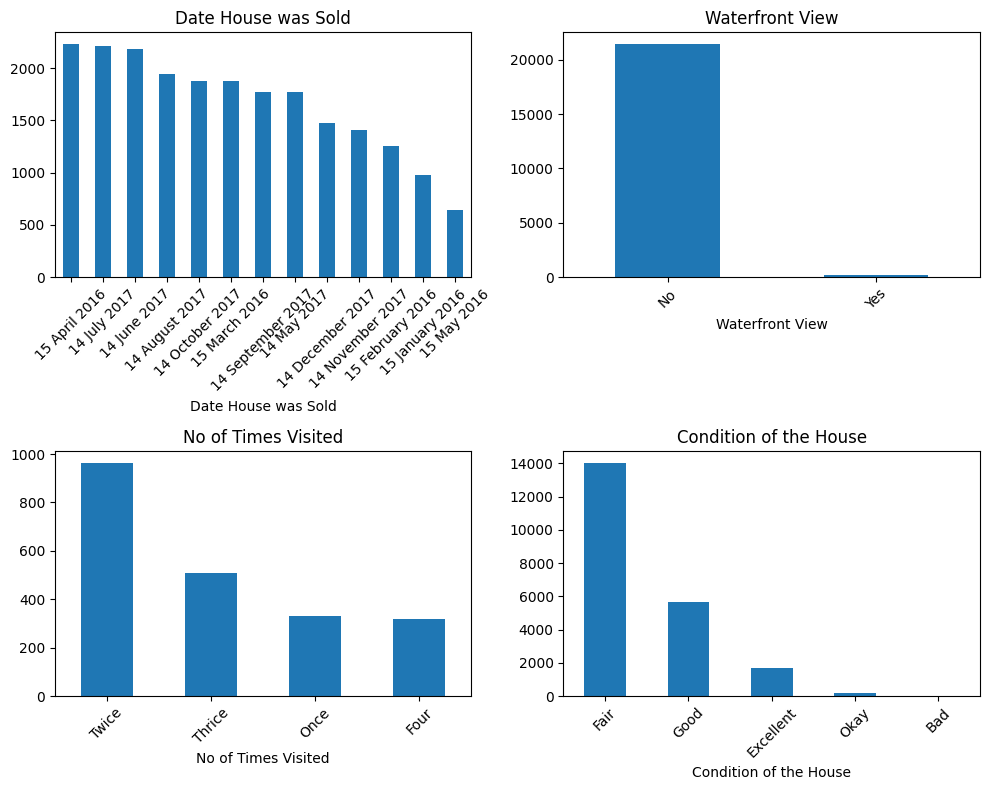

In [53]:
plt.figure(figsize=(10,8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    house_df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [54]:
#since replacing categorical null values with mode will introduce data imbalance, we can go for removing the rows with null values

In [55]:
house_df.dropna(axis=0, inplace=True)
house_df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,0


In [56]:
print("After:", house_df.shape)

After: (2123, 21)


#Outlier Removal

In [57]:
house_df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.123000e+03,2.123000e+03,2123.000000,2123.000000,2123.000000,2.123000e+03,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000
mean,4.677559e+09,9.400548e+05,3.596797,2.528497,2834.265662,2.361442e+04,1.523787,8.342911,2173.580782,660.684880,52.576072,200.118700,98092.702308,47.564069,-122.251473,2554.635893,18095.875648
std,2.899284e+09,6.625349e+05,0.995006,0.919895,1238.490638,6.898133e+04,0.548775,1.254278,1026.511614,614.828688,28.934442,599.415149,60.913274,0.122449,0.142013,782.992417,41356.764060
min,3.100016e+07,1.540000e+05,0.000000,0.000000,440.000000,6.900000e+02,1.000000,2.000000,440.000000,0.000000,3.000000,0.000000,98001.000000,47.177600,-122.514000,399.000000,1057.000000
25%,2.212650e+09,5.350000e+05,3.000000,1.750000,2010.000000,6.000000e+03,1.000000,7.500000,1450.000000,0.000000,28.000000,0.000000,98034.000000,47.512100,-122.369000,1990.000000,6000.000000
50%,4.058802e+09,7.500000e+05,4.000000,2.500000,2650.000000,9.377000e+03,1.500000,8.000000,1940.000000,650.000000,53.000000,0.000000,98107.000000,47.571000,-122.278000,2490.000000,9040.000000
75%,7.556755e+09,1.150000e+06,4.000000,3.000000,3455.000000,1.593400e+04,2.000000,9.000000,2660.000000,1050.000000,71.000000,0.000000,98136.000000,47.648350,-122.190000,2980.000000,14256.000000
max,9.830200e+09,7.700000e+06,10.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777200,-121.480000,6110.000000,858132.000000


In [58]:
#gives unique values
house_df['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

In [59]:
for col in cat_cols:
    print(col, ":", house_df[col].unique())

Date House was Sold : ['15 January 2016' '14 August 2017' '15 March 2016' '14 December 2017'
 '14 May 2017' '14 November 2017' '14 October 2017' '14 July 2017'
 '15 April 2016' '15 February 2016' '14 September 2017' '15 May 2016'
 '14 June 2017']
Waterfront View : ['No' 'Yes']
No of Times Visited : ['Thrice' 'Four' 'Twice' 'Once']
Condition of the House : ['Fair' 'Excellent' 'Good' 'Okay' 'Bad']


In [60]:
#gives no of unique values
house_df['Sale Price'].nunique()

799

In [61]:
for col in num_cols:
    print(col, ":", house_df[col].nunique())

ID : 2115
Sale Price : 799
No of Bedrooms : 10
No of Bathrooms : 27
Flat Area (in Sqft) : 546
Lot Area (in Sqft) : 1616
No of Floors : 6
Overall Grade : 8
Area of the House from Basement (in Sqft) : 464
Basement Area (in Sqft) : 239
Age of House (in Years) : 116
Renovated Year : 53
Zipcode : 69
Latitude : 1589
Longitude : 492
Living Area after Renovation (in Sqft) : 389
Lot Area after Renovation (in Sqft) : 1493


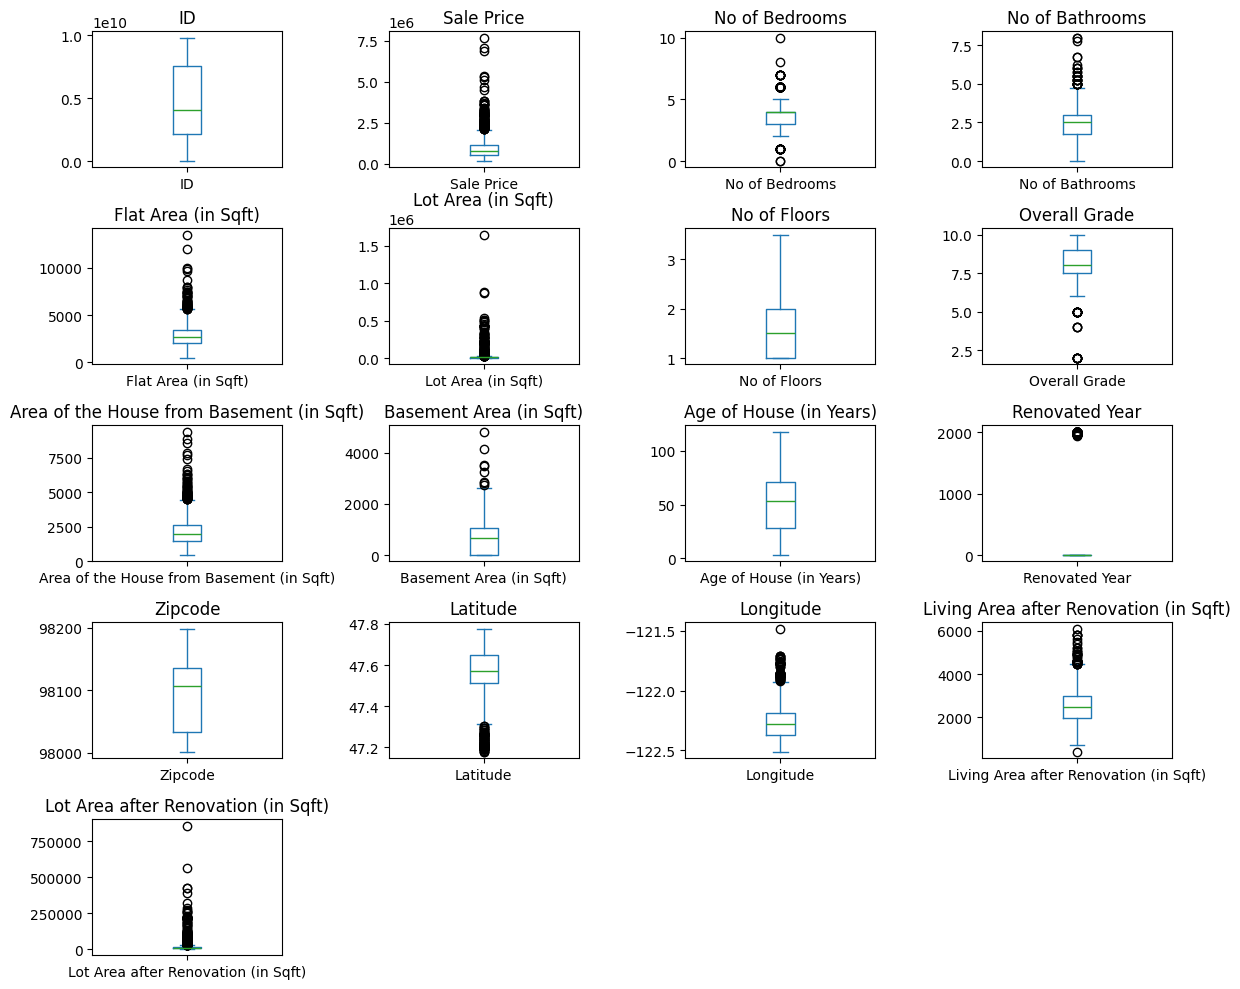

In [62]:
#we use box plot to identify outliers
plt.figure(figsize=(12,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)
    house_df[col].plot(kind='box')
    plt.title(col)

plt.tight_layout()
plt.show()

In [63]:
Q1 = house_df[num_cols].quantile(0.25)
Q3 = house_df[num_cols].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((house_df[num_cols] > upper_limit) |
            (house_df[num_cols] < lower_limit)).any(axis=1)

outliers_df = house_df[outliers]

outlier_percentage = len(outliers_df) * 100 / len(house_df)

print(outlier_percentage)

33.01931229392369


In [64]:
house_df[num_cols] = house_df[num_cols].clip(lower_limit, upper_limit, axis=1)

In [65]:
cat_cols = house_df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


#Remove unwanted column

In [66]:
corr_matrix = house_df[num_cols].corr(method='pearson')
corr_matrix

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,-0.072649,0.024286,-0.016676,-0.035841,-0.160386,0.002031,-0.018124,-0.021803,-0.032779,-0.042994,NaN,-0.025661,0.027176,0.022131,-0.019550,-0.159407
Sale Price,-0.072649,1.000000,0.321758,0.574034,0.702654,0.147436,0.332222,0.632164,0.629460,0.341227,-0.129485,NaN,-0.162044,0.344831,0.047368,0.606198,0.150239
No of Bedrooms,0.024286,0.321758,1.000000,0.557528,0.568661,0.090772,0.162433,0.358270,0.443987,0.384059,-0.200036,NaN,-0.146777,0.055780,0.171404,0.373746,0.071765
No of Bathrooms,-0.016676,0.574034,0.557528,1.000000,0.779972,0.166094,0.453978,0.612445,0.706862,0.370023,-0.444621,NaN,-0.200685,0.094606,0.204804,0.510373,0.145351
Flat Area (in Sqft),-0.035841,0.702654,0.568661,0.779972,1.000000,0.288646,0.373160,0.710467,0.856225,0.544760,-0.400557,NaN,-0.239522,0.100883,0.232149,0.681569,0.271641
Lot Area (in Sqft),-0.160386,0.147436,0.090772,0.166094,0.288646,1.000000,-0.056490,0.154874,0.311980,0.055904,-0.181466,NaN,-0.313000,-0.288356,0.337404,0.293073,0.872166
No of Floors,0.002031,0.332222,0.162433,0.453978,0.373160,-0.056490,1.000000,0.421982,0.583266,-0.206660,-0.310056,NaN,-0.056679,0.092337,0.091867,0.179776,-0.047330
Overall Grade,-0.018124,0.632164,0.358270,0.612445,0.710467,0.154874,0.421982,1.000000,0.685944,0.255094,-0.461375,NaN,-0.222850,0.140801,0.181932,0.621841,0.163896
Area of the House from Basement (in Sqft),-0.021803,0.629460,0.443987,0.706862,0.856225,0.311980,0.583266,0.685944,1.000000,0.050687,-0.442801,NaN,-0.260319,0.046824,0.308067,0.612836,0.301970
Basement Area (in Sqft),-0.032779,0.341227,0.384059,0.370023,0.544760,0.055904,-0.206660,0.255094,0.050687,1.000000,-0.055744,NaN,-0.050605,0.120402,-0.044517,0.330003,0.037485


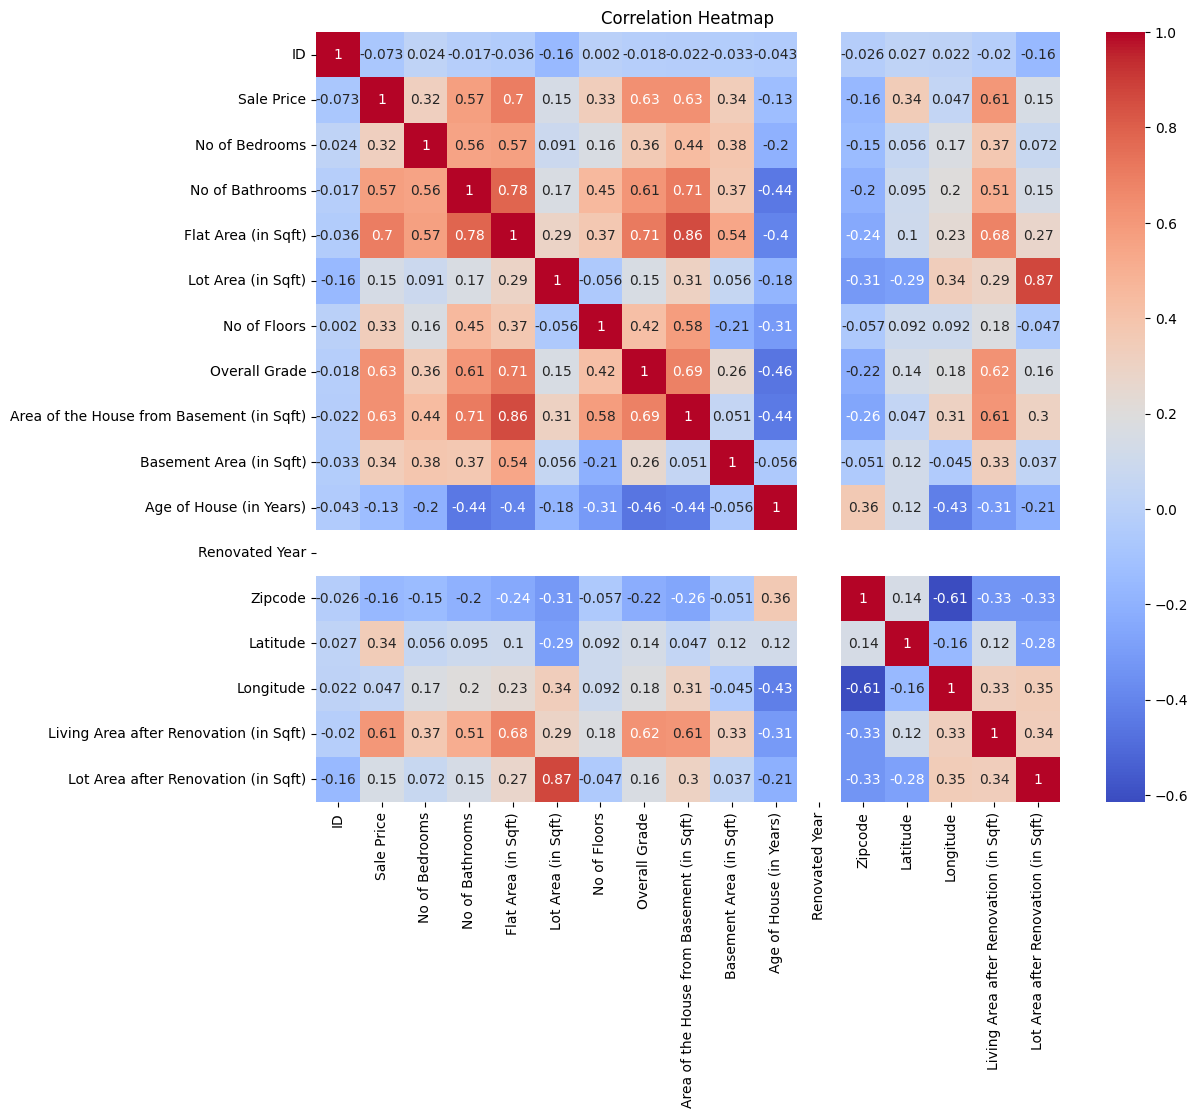

In [68]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Dropping unnecessary and redundant features

# 1. ID column is just an identifier and does not contribute to prediction
# 2. 'Area of the House from Basement (in Sqft)' is highly correlated with 'Flat Area (in Sqft)'
#    → both carry similar information, so one is removed to avoid multicollinearity
# 3. 'Lot Area after Renovation (in Sqft)' is highly correlated with 'Lot Area (in Sqft)'
#    → removing redundant feature

In [69]:
house_df.drop([
    'ID',
    'Area of the House from Basement (in Sqft)',
    'Lot Area after Renovation (in Sqft)'
], axis=1, inplace=True)

In [73]:
num_features = house_df.select_dtypes(include=['number']).columns.drop('Sale Price')

In [76]:
num_features


Index(['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)'],
      dtype='object')

In [77]:
#Encoding categorical columns
cat_cols = house_df.select_dtypes(include=['object']).columns

cat_cols

Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')

In [78]:
le = LabelEncoder()

In [79]:
house_df['Waterfront View'] = le.fit_transform(house_df['Waterfront View'])   #binary encoding

In [80]:
house_df = pd.get_dummies(
    house_df,
    columns=['Condition of the House'],
    drop_first=True
)   #one hot encoding

In [81]:
house_df['Date House was Sold'] = pd.to_datetime(house_df['Date House was Sold'])

house_df['sale_year'] = house_df['Date House was Sold'].dt.year
house_df['sale_month'] = house_df['Date House was Sold'].dt.month

house_df.drop('Date House was Sold', axis=1, inplace=True)

In [ ]:
#Categorical variables were encoded using Label Encoding for binary features and One-Hot Encoding for multi-category features.
# Date variables were transformed into meaningful numerical components

In [82]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2123 entries, 15 to 21598
Data columns (total 22 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Sale Price                              2123 non-null   float64
 1   No of Bedrooms                          2123 non-null   float64
 2   No of Bathrooms                         2123 non-null   float64
 3   Flat Area (in Sqft)                     2123 non-null   float64
 4   Lot Area (in Sqft)                      2123 non-null   float64
 5   No of Floors                            2123 non-null   float64
 6   Waterfront View                         2123 non-null   int64  
 7   No of Times Visited                     2123 non-null   object 
 8   Overall Grade                           2123 non-null   float64
 9   Basement Area (in Sqft)                 2123 non-null   int64  
 10  Age of House (in Years)                 2123 non-null   int64  

##Scaling

In [89]:
#before scaling

house_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),sale_year,sale_month
count,2.123000e+03,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.0,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000
mean,8.928951e+05,3.580075,2.516545,2800.318182,12275.760716,1.523787,0.076778,8.358455,657.585492,52.576072,0.0,98092.702308,47.567076,-122.254759,2545.953839,2016.670749,6.501649
std,4.905250e+05,0.920979,0.876823,1112.188642,8452.383083,0.548775,0.266302,1.197648,601.285458,28.934442,0.0,60.913274,0.114774,0.132301,755.949995,0.470052,3.109284
min,1.540000e+05,1.500000,0.000000,440.000000,690.000000,1.000000,0.000000,5.250000,0.000000,3.000000,0.0,98001.000000,47.307725,-122.514000,505.000000,2016.000000,1.000000
25%,5.350000e+05,3.000000,1.750000,2010.000000,6000.000000,1.000000,0.000000,7.500000,0.000000,28.000000,0.0,98034.000000,47.512100,-122.369000,1990.000000,2016.000000,4.000000
50%,7.500000e+05,4.000000,2.500000,2650.000000,9377.000000,1.500000,0.000000,8.000000,650.000000,53.000000,0.0,98107.000000,47.571000,-122.278000,2490.000000,2017.000000,6.000000
75%,1.150000e+06,4.000000,3.000000,3455.000000,15934.000000,2.000000,0.000000,9.000000,1050.000000,71.000000,0.0,98136.000000,47.648350,-122.190000,2980.000000,2017.000000,9.000000
max,2.072500e+06,5.500000,4.875000,5622.500000,30835.000000,3.500000,1.000000,10.000000,2625.000000,118.000000,0.0,98199.000000,47.777200,-121.921500,4465.000000,2017.000000,12.000000


In [90]:
num_features = house_df.select_dtypes(include=['number']).columns.drop('Sale Price')

In [91]:
scaler = MinMaxScaler()
house_df[num_features] = scaler.fit_transform(house_df[num_features])

In [92]:
#after scaling

house_df.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Overall Grade,Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),sale_year,sale_month
count,2.123000e+03,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.0,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000,2123.000000
mean,8.928951e+05,0.520019,0.516214,0.455440,0.384334,0.209515,0.076778,0.654412,0.250509,0.431096,0.0,0.463143,0.552428,0.437537,0.515392,0.670749,0.500150
std,4.905250e+05,0.230245,0.179861,0.214605,0.280391,0.219510,0.266302,0.252137,0.229061,0.251604,0.0,0.307643,0.244473,0.223292,0.190896,0.470052,0.282662
min,1.540000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.350000e+05,0.375000,0.358974,0.302943,0.176149,0.000000,0.000000,0.473684,0.000000,0.217391,0.0,0.166667,0.435327,0.244726,0.375000,0.000000,0.272727
50%,7.500000e+05,0.625000,0.512821,0.426435,0.288174,0.200000,0.000000,0.578947,0.247619,0.434783,0.0,0.535354,0.560786,0.398312,0.501263,1.000000,0.454545
75%,1.150000e+06,0.625000,0.615385,0.581766,0.505689,0.400000,0.000000,0.789474,0.400000,0.591304,0.0,0.681818,0.725544,0.546835,0.625000,1.000000,0.727273
max,2.072500e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#Train-Test Split

In [93]:
#Separate features and target
X = house_df.drop('Sale Price', axis=1)
y = house_df['Sale Price']

In [94]:
#Split the data (80–20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [95]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1698, 21)
X_test: (425, 21)
y_train: (1698,)
y_test: (425,)


In [96]:
#The dataset was split into training (80%) and testing (20%) sets. The target variable was separated from the feature set before splitting.
# A random state was used to ensure reproducibility

In [ ]:
#The dataset was preprocessed by handling missing values, removing duplicates, treating outliers using the IQR method,
#encoding categorical variables, and scaling numerical features.
#Finally, the dataset was split into training and testing sets (80:20) for model development.